Количество строк: 186,850
Количество столбцов: 6
<class 'pandas.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Order ID          186305 non-null  str  
 1   Product           186305 non-null  str  
 2   Quantity Ordered  186305 non-null  str  
 3   Price Each        186305 non-null  str  
 4   Order Date        186305 non-null  str  
 5   Purchase Address  186305 non-null  str  
dtypes: str(6)
memory usage: 8.6 MB
Строк после очистки: 185,687


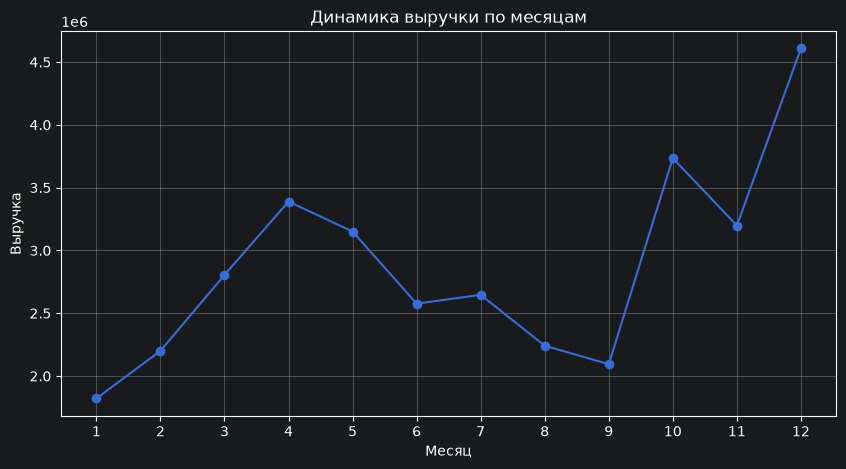

Месяц с максимальной выручкой: 12.0
Выручка: $4,608,295.70


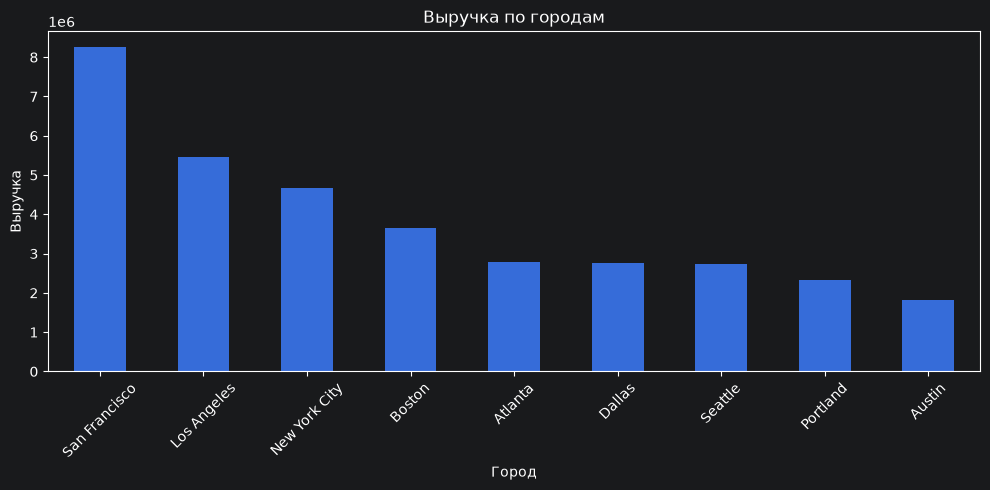

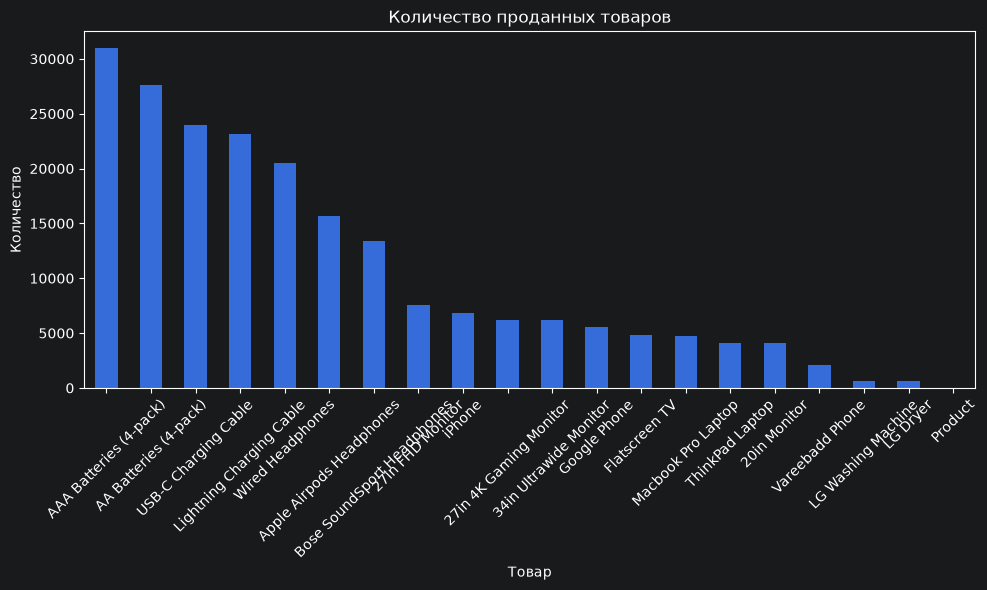

Средний чек: $193.15


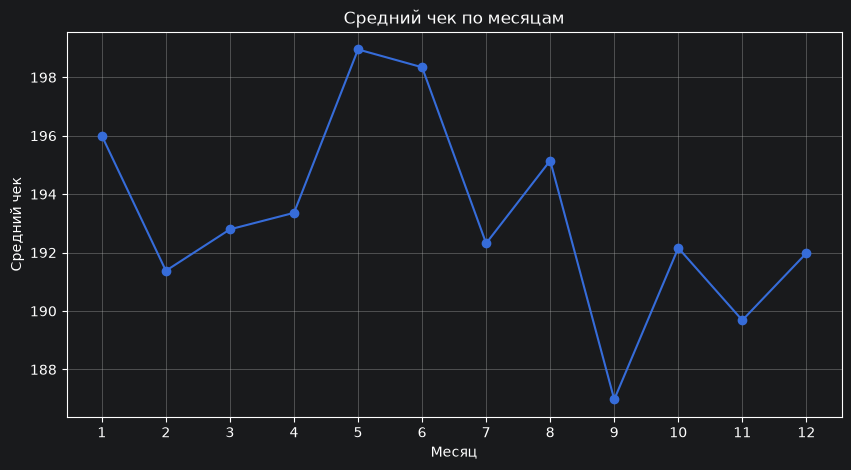

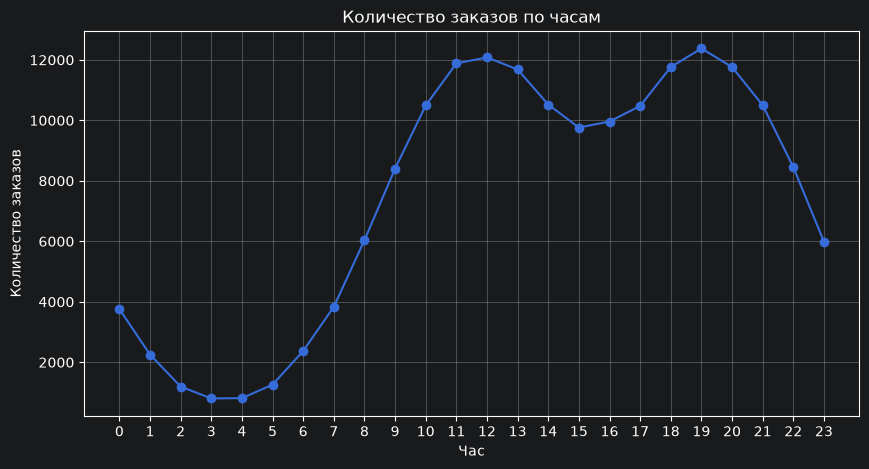

5 часов с наибольшим количеством заказов:
Hour
19.0    12377
12.0    12082
11.0    11882
20.0    11763
18.0    11761
Name: Order ID, dtype: int64


,Метрика,Значение
0,Общая выручка,3.446554e+07
1,Средний чек,1.931513e+02
2,Количество заказов,1.784380e+05
3,Количество проданных товаров,2.088120e+05


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
pd.set_option("display.max_columns", None)

data_path = Path("data")
files = list(data_path.glob("Sales_*.csv"))
df = pd.concat(
    [pd.read_csv(file) for file in files],
    ignore_index=True
)
df.head()
print(f"Количество строк: {len(df):,}")
print(f"Количество столбцов: {df.shape[1]}")
df.info()
df.head()
df.isna().sum()

df.describe(include="all")

#удаляем пустые строки
df = df.dropna(how="all").copy()
#удаляем дубликаты
df = df.drop_duplicates().copy()
print(f"Строк после очистки: {len(df):,}")

df.dtypes

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format = "%m/%d/%y %H:%M",
    errors="coerce"
)

#доп признаки
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Hour"] = df["Order Date"].dt.hour

df["Quantity Ordered"] = pd.to_numeric(
    df["Quantity Ordered"],
    errors="coerce"
)

df["Price Each"] = pd.to_numeric(
    df["Price Each"],
    errors="coerce"
)
df["Sales"] = (
    df["Quantity Ordered"] *
    df["Price Each"]
)
df[["Product", "Quantity Ordered", "Price Each", "Sales"]].head()

#анализ по месяцам
monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .sort_index()
)
monthly_sales

#график
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)
plt.title("Динамика выручки по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Выручка")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

#месяца с макс выручкой
best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()
print(f"Месяц с максимальной выручкой: {best_month}")
print(f"Выручка: ${best_month_sales:,.2f}")

#Города
df["City"] = (
    df["Purchase Address"]
      .str.split(",")
      .str[1]
      .str.strip()
)

city_sales = (
    df.groupby("City")["Sales"]
      .sum()
      .sort_values(ascending=False)
)
city_sales

plt.figure(figsize=(10, 5))
city_sales.plot(kind="bar")
plt.title("Выручка по городам")
plt.xlabel("Город")
plt.ylabel("Выручка")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#кол во проданных единиц
product_quantity = (
    df.groupby("Product")["Quantity Ordered"]
      .sum()
      .sort_values(ascending=False)
)
product_quantity

#график
plt.figure(figsize=(10, 6))
product_quantity.plot(kind="bar")
plt.title("Количество проданных товаров")
plt.xlabel("Товар")
plt.ylabel("Количество")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#стоимость каждого заказа
order_sales = (
    df.groupby("Order ID")["Sales"]
      .sum()
)

#средний чек
average_check = order_sales.mean()
print(f"Средний чек: ${average_check:,.2f}")

monthly_average_check = (
    df.groupby(["Order ID", "Month"])["Sales"]
      .sum()
      .groupby("Month")
      .mean()
)
monthly_average_check

#график
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_average_check.index,
    monthly_average_check.values,
    marker="o"
)
plt.title("Средний чек по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Средний чек")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()


#анализ времени покупок
hourly_orders = (
    df.groupby("Hour")["Order ID"]
      .nunique()
)
hourly_orders

#график
plt.figure(figsize=(10, 5))
plt.plot(
    hourly_orders.index,
    hourly_orders.values,
    marker="o"
)
plt.title("Количество заказов по часам")
plt.xlabel("Час")
plt.ylabel("Количество заказов")
plt.xticks(range(24))
plt.grid(True)
plt.show()

#часы с наибольшим количеством заказов
top_hours = (
    hourly_orders
    .sort_values(ascending=False)
    .head(5)
)
print("5 часов с наибольшим количеством заказов:")
print(top_hours)


#итог
summary = pd.DataFrame({
    "Метрика": [
        "Общая выручка",
        "Средний чек",
        "Количество заказов",
        "Количество проданных товаров"
    ],
    "Значение": [
        df["Sales"].sum(),
        average_check,
        df["Order ID"].nunique(),
        df["Quantity Ordered"].sum()
    ]
})
summary


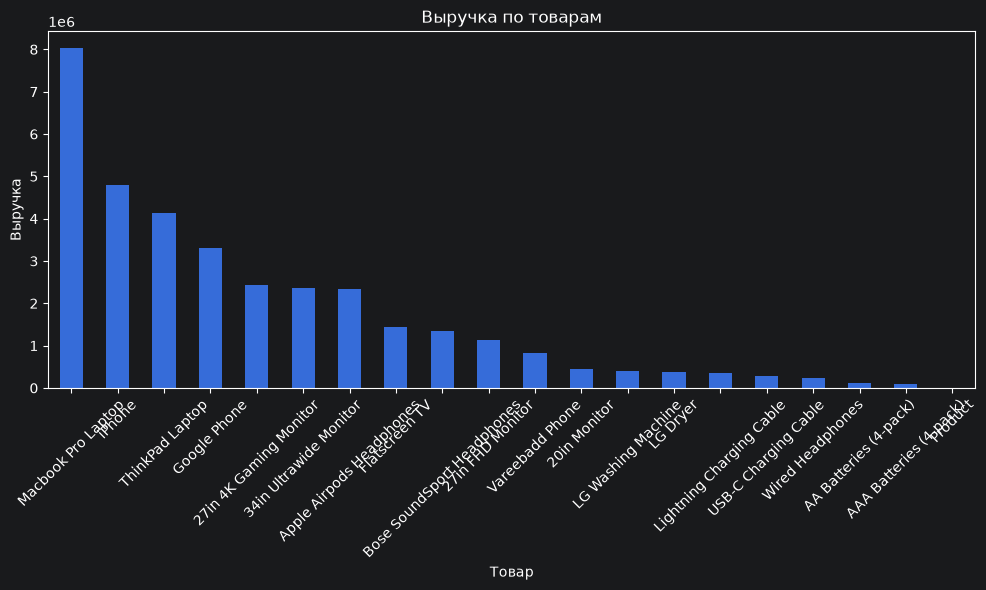

In [12]:
#самый прибыльный продукт
product_sales = (
    df.groupby("Product")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

product_sales

plt.figure(figsize=(10, 6))

product_sales.plot(kind="bar")

plt.title("Выручка по товарам")
plt.xlabel("Товар")
plt.ylabel("Выручка")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()